In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df1 = pd.read_csv("Unemployment in India.csv")
df2 = pd.read_csv("Unemployment_Rate_upto_11_2020.csv")

In [4]:
df1.columns = df1.columns.str.strip()
df2.columns = df2.columns.str.strip()

In [5]:
print("\n FIRST DATASET")
print(df1.head())

print("\n SECOND DATASET")
print(df2.head())


 FIRST DATASET
           Region         Date Frequency  Estimated Unemployment Rate (%)  \
0  Andhra Pradesh   31-05-2019   Monthly                             3.65   
1  Andhra Pradesh   30-06-2019   Monthly                             3.05   
2  Andhra Pradesh   31-07-2019   Monthly                             3.75   
3  Andhra Pradesh   31-08-2019   Monthly                             3.32   
4  Andhra Pradesh   30-09-2019   Monthly                             5.17   

   Estimated Employed  Estimated Labour Participation Rate (%)   Area  
0          11999139.0                                    43.24  Rural  
1          11755881.0                                    42.05  Rural  
2          12086707.0                                    43.50  Rural  
3          12285693.0                                    43.97  Rural  
4          12256762.0                                    44.68  Rural  

 SECOND DATASET
           Region         Date Frequency  Estimated Unemployment Rate (%

In [6]:
print("\n DATASET INFO")
print(df1.info())

print("\n STATISTICAL SUMMARY")
print(df1.describe())


 DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 7 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Region                                   740 non-null    str    
 1   Date                                     740 non-null    str    
 2   Frequency                                740 non-null    str    
 3   Estimated Unemployment Rate (%)          740 non-null    float64
 4   Estimated Employed                       740 non-null    float64
 5   Estimated Labour Participation Rate (%)  740 non-null    float64
 6   Area                                     740 non-null    str    
dtypes: float64(3), str(4)
memory usage: 42.1 KB
None

 STATISTICAL SUMMARY
       Estimated Unemployment Rate (%)  Estimated Employed  \
count                       740.000000        7.400000e+02   
mean                         11.787946        7.204460e+06   


In [7]:
print("\n MISSING VALUES")
print(df1.isnull().sum())

print(df2.isnull().sum())


 MISSING VALUES
Region                                     28
Date                                       28
Frequency                                  28
Estimated Unemployment Rate (%)            28
Estimated Employed                         28
Estimated Labour Participation Rate (%)    28
Area                                       28
dtype: int64
Region                                     0
Date                                       0
Frequency                                  0
Estimated Unemployment Rate (%)            0
Estimated Employed                         0
Estimated Labour Participation Rate (%)    0
Region.1                                   0
longitude                                  0
latitude                                   0
dtype: int64


In [8]:
df1 = df1.dropna()
df2 = df2.dropna()

In [10]:
df1['Date'] = pd.to_datetime(df1['Date'], dayfirst=True)
df2['Date'] = pd.to_datetime(df2['Date'], dayfirst=True)

In [11]:
avg_unemployment = df1['Estimated Unemployment Rate (%)'].mean()

print("\n AVERAGE UNEMPLOYMENT RATE")
print(avg_unemployment)



 AVERAGE UNEMPLOYMENT RATE
11.787945945945946


In [12]:
state_unemployment = df1.groupby('Region')['Estimated Unemployment Rate (%)'].mean()

print("\n STATE WISE UNEMPLOYMENT")
print(state_unemployment)


 STATE WISE UNEMPLOYMENT
Region
Andhra Pradesh       7.477143
Assam                6.428077
Bihar               18.918214
Chandigarh          15.991667
Chhattisgarh         9.240357
Delhi               16.495357
Goa                  9.274167
Gujarat              6.663929
Haryana             26.283214
Himachal Pradesh    18.540357
Jammu & Kashmir     16.188571
Jharkhand           20.585000
Karnataka            6.676071
Kerala              10.123929
Madhya Pradesh       7.406429
Maharashtra          7.557500
Meghalaya            4.798889
Odisha               5.657857
Puducherry          10.215000
Punjab              12.031071
Rajasthan           14.058214
Sikkim               7.249412
Tamil Nadu           9.284286
Telangana            7.737857
Tripura             28.350357
Uttar Pradesh       12.551429
Uttarakhand          6.582963
West Bengal          8.124643
Name: Estimated Unemployment Rate (%), dtype: float64


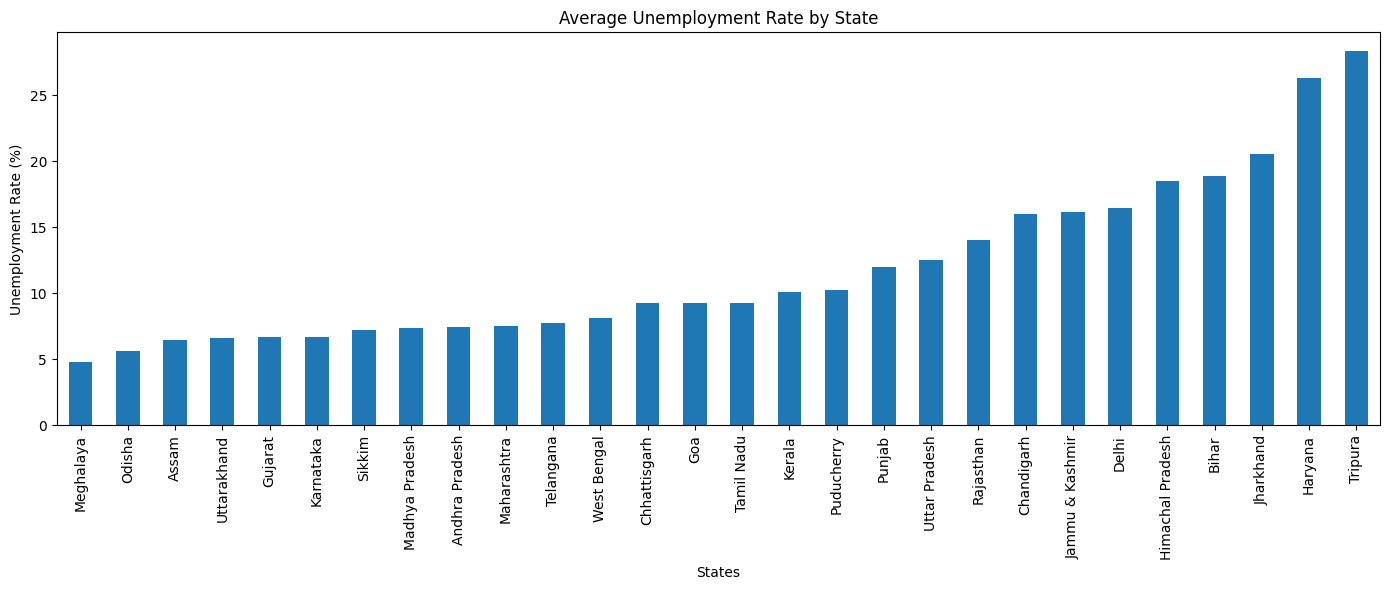

In [13]:
plt.figure(figsize=(14,6))

state_unemployment.sort_values().plot(kind='bar')

plt.title("Average Unemployment Rate by State")
plt.xlabel("States")
plt.ylabel("Unemployment Rate (%)")
plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

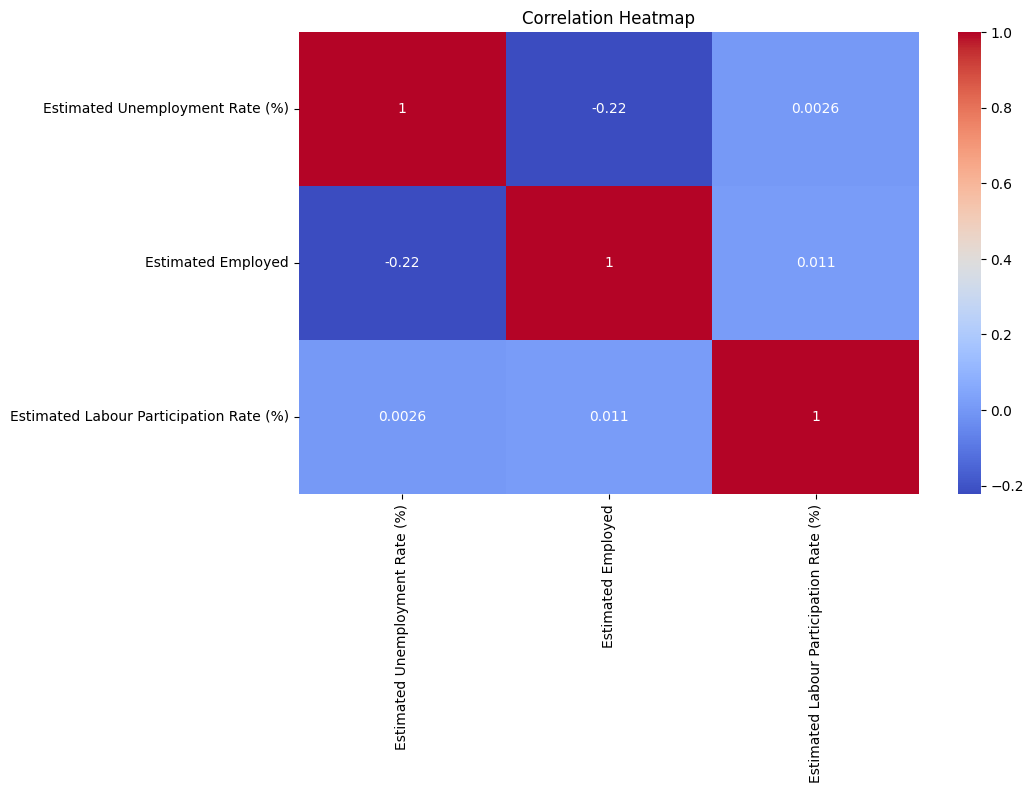

In [14]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df1.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()


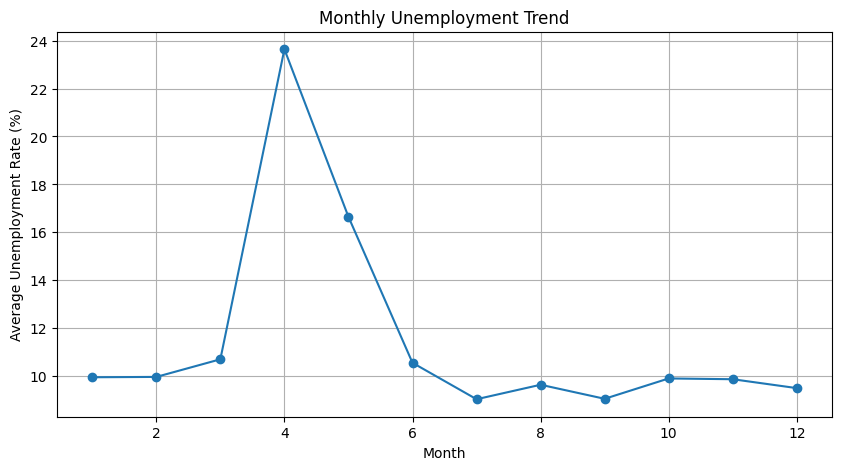

In [15]:
df1['Month'] = df1['Date'].dt.month

monthly_trend = df1.groupby('Month')['Estimated Unemployment Rate (%)'].mean()

plt.figure(figsize=(10,5))

monthly_trend.plot(marker='o')

plt.title("Monthly Unemployment Trend")
plt.xlabel("Month")
plt.ylabel("Average Unemployment Rate (%)")

plt.grid(True)

plt.show()

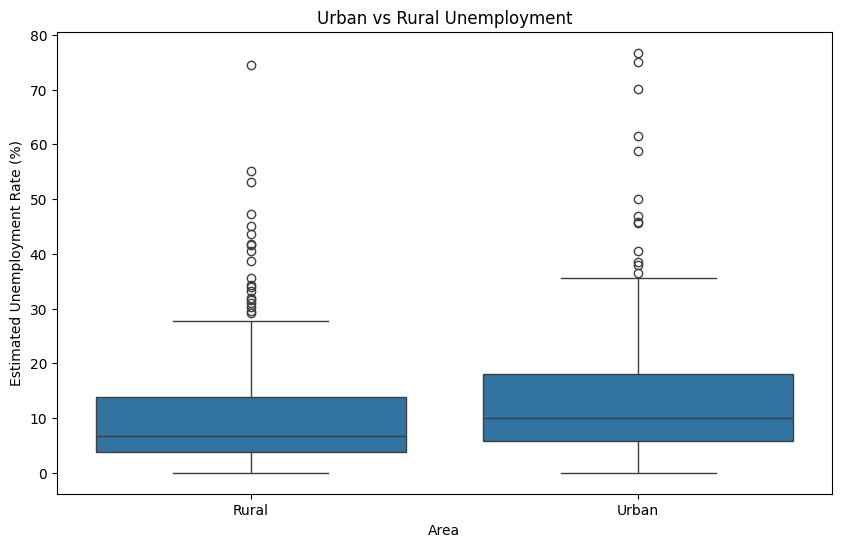

In [16]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df1,
    x='Area',
    y='Estimated Unemployment Rate (%)'
)

plt.title("Urban vs Rural Unemployment")

plt.show()


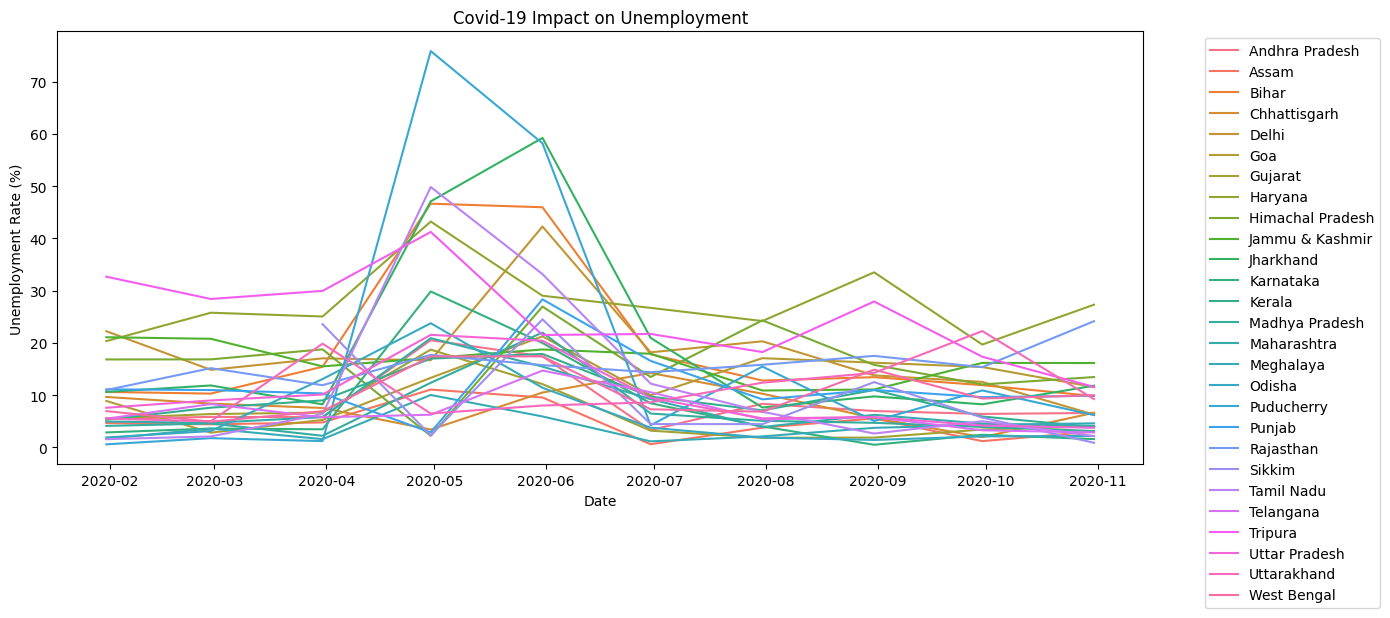

In [17]:
plt.figure(figsize=(14,6))

sns.lineplot(
    data=df2,
    x='Date',
    y='Estimated Unemployment Rate (%)',
    hue='Region'
)

plt.title("Covid-19 Impact on Unemployment")
plt.xlabel("Date")
plt.ylabel("Unemployment Rate (%)")

plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')

plt.tight_layout()

plt.show()


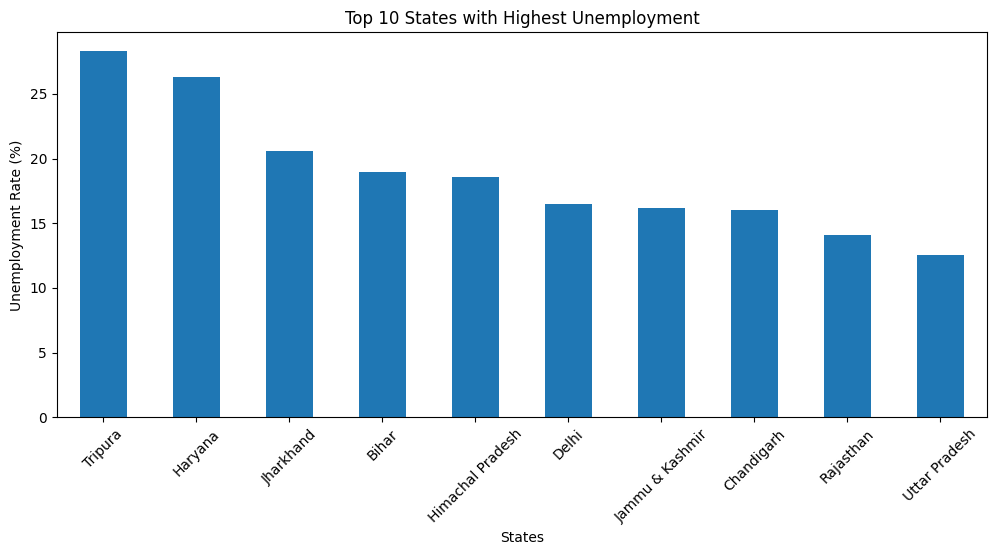

In [18]:
top_states = state_unemployment.sort_values(ascending=False).head(10)

plt.figure(figsize=(12,5))

top_states.plot(kind='bar')

plt.title("Top 10 States with Highest Unemployment")
plt.xlabel("States")
plt.ylabel("Unemployment Rate (%)")

plt.xticks(rotation=45)

plt.show()

In [19]:

df1.to_csv("cleaned_unemployment_data.csv", index=False)

In [20]:
print("\n PROJECT INSIGHTS")

print("1. Unemployment rates increased significantly during the Covid-19 period.")

print("2. Some states showed very high unemployment rates compared to others.")

print("3. There is a noticeable difference between urban and rural unemployment rates.")

print("4. Monthly trend analysis shows fluctuations in unemployment over time.")

print("5. Effective government employment policies are important to reduce unemployment.")


 PROJECT INSIGHTS
1. Unemployment rates increased significantly during the Covid-19 period.
2. Some states showed very high unemployment rates compared to others.
3. There is a noticeable difference between urban and rural unemployment rates.
4. Monthly trend analysis shows fluctuations in unemployment over time.
5. Effective government employment policies are important to reduce unemployment.
